In [27]:
from myutils import parallelize

from src import *

In [28]:
freq_list = np.linspace(0.1, 0.4, 61)

sampling_rate = 20
pic_time = (1 / (sampling_rate * freq_list) / 2 * 1e6).astype(int)

# Consider rounding errors
real_freq_list = 1 / (pic_time * 2) * 1e6 / sampling_rate

np.random.normal(6e-3, 8e-4) 可能差不多, 还有 (6e-3, 280e-6)

pic_time 可能有一个误差, 10us似乎合适

np.random.normal(3e-3, 0.3e-3) 非常像, (2.8e-3, 0.5e-3)也像

In [29]:
@parallelize()
def main(f, measurement, A):
    cropped, noise = [], []
    for _ in range(200):
        meta = MetaData(measurement, f, A, 0)
        meta_ = MetaData(measurement, np.round(f, 3), A, 0) # MetaData for save file, match the experiments.
        sim = Simulator(meta, delay=np.random.normal(2.8e-3, 0.48e-3), waveform='sin')
        cropped_, noise_ = sim.gen()
        cropped.append(cropped_)
        noise.append(noise_)
    c = Estimates(np.array(cropped), meta_, noise=np.array(noise).mean(-1))
    return Estimation.FromEstimates(c)

In [30]:
cs_di, cs_spade = main(real_freq_list, 'DI', 3*DMD.PIXEL_SIZE/2), main(real_freq_list, 'SPADE', 3*DMD.PIXEL_SIZE/2)

In [32]:
for i in range(61):
    cs_di[i].savez('__simulations__/di_3px')
    cs_spade[i].savez('__simulations__/spade_3px')

In [21]:
size = 9
(size / 2.54, size / 2.54 / 3 * 2)

(3.543307086614173, 2.3622047244094486)

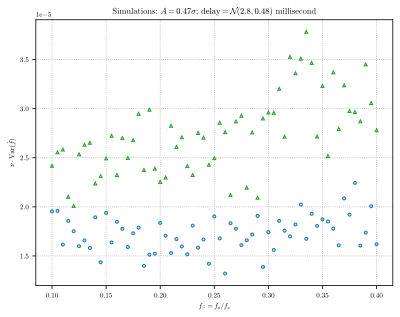

In [31]:
plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'


# di_x = [cs[i].metadata.ground_truth for i in range(61)]
di_y = [cs_di[i].frequency_estimates.var() * cs_di[i].photons.mean() for i in range(61)]
spade_y = [cs_spade[i].frequency_estimates.var() * cs_spade[i].photons.mean() for i in range(61)]

plt.plot(freq_list, spade_y, 
        marker='o', linestyle='', markersize=3,
        markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

plt.plot(freq_list, di_y,
        marker='^', linestyle='', markersize=3,
        markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')

plt.grid(True, linestyle=':')
plt.title(r'Simulations: $A = 0.47\sigma$; ${\rm delay} =\mathcal{N}(2.8, 0.48)$ millisecond')
plt.xlabel(r'$f := f_o / f_s$')
plt.ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
plt.show()

In [33]:
raise

RuntimeError: No active exception to reraise

In [ ]:
# @cache
# @parallelize()
# def main(freq, repeat=200):
#     meta = MetaData('DI', freq, 5*DMD.PIXEL_SIZE/2, 0)
#     c = Simulator(meta)
#     cropped_data = np.array([c.gen(400) for _ in range(repeat)])
#     td = td_estimator(meta.measurement, cropped_data)
#     f_est = np.array([freq_estimator(td_) for td_ in td])
#     return f_est


In [ ]:
f_est = np.load(r'__simulations__\di_sin.npy')

plot(np.linspace(0.1, 0.4, 3000), f_est.var(-1) * 400, label='DI')

x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plot(x_axis, crb, 'r-',title=r'$s[n;\omega] =A \sin\omega n; A= 0.47\sigma$', label='(Q)CRB')
plot(x_axis, 1.3 * crb, 'r--', ylabel=r'$\nu\cdot{\rm Var}(\hat f)$')
plot(x_axis, 0.7 * crb, 'r--', xlabel=r'$f:=f_o/f_s$')

In [ ]:
f_est = np.load(r'__simulations__\di_sign.npy')

plot(np.linspace(0.1, 0.4, 3000), f_est.var(-1) * 400, label='DI')

x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plot(x_axis, crb, 'r-',title=r'$s[n;\omega] =A~{\rm sign}(\sin\omega n); A= 0.47\sigma$', label='(Q)CRB')
plot(x_axis, 1.3 * crb, 'r--', ylabel=r'$\nu\cdot{\rm Var}(\hat f)$')
plot(x_axis, 0.7 * crb, 'r--', xlabel=r'$f:=f_o/f_s$')

In [ ]:
@cache
@parallelize()
def main(freq, repeat=200):
    meta = MetaData('SPADE', freq, 5*DMD.PIXEL_SIZE/2, 0, 20)
    c = Simulator(meta, 'sign')
    cropped_data = np.array([c.gen(60) for _ in range(repeat)])
    td = td_estimator(meta.measurement, cropped_data, spade_method='zhou2023')
    f_est = np.array([freq_estimator(td_) for td_ in td])
    return f_est


In [ ]:
f_est = main(np.linspace(0.1, 0.4, 3000))

In [ ]:
np.save('spade_sign_zhou2023.npy', f_est)

In [ ]:
plot(np.linspace(0.1, 0.4, 3000), np.array(f_est).var(-1) * 60, label='DI')

x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plot(x_axis, crb, 'r-',title=r'$s[n;\omega] =A~{\rm sign}(\sin\omega n); A= 0.47\sigma$', label='(Q)CRB')
plot(x_axis, 1.3 * crb, 'r--', ylabel=r'$\nu\cdot{\rm Var}(\hat f)$')
plot(x_axis, 0.7 * crb, 'r--', xlabel=r'$f:=f_o/f_s$')

In [ ]:

meta = MetaData('SPADE', 0.01, 5*DMD.PIXEL_SIZE/2, 0, sampling_rate=1)
c = Simulator(meta)
cropped_data = np.array([c.gen(1000, sample_length=200) for _ in range(200)])

In [ ]:
td = td_estimator('SPADE', cropped_data, spade_method='zhou2023')

In [ ]:
plot(td.mean(0), title=r'SPADE time-domain; $s\approx 96.87 {\rm \mu m}$', ylabel=r'${\rm \mu m}$', xlabel='time')
axline(h=5*DMD.PIXEL_SIZE,c='r', w=1)

$$
\frac{n1- n2}{ns} = \frac s\sigma exp(-s^2 / 4\sigma^2)
$$

$$
s\to 0; noise = 0
$$

$$
s = \sigma\frac{n1-n2}{n1+n2}
$$